In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

from src.behavioral.nmd_model import NMDModel

In [2]:
# a synthetic deposit portfolio
deposit_portfolio = {
    'Retail Current': NMDModel(
        balance = 300000,
        product_type = 'retail_current',
        core_ratio = 0.9,
        avg_life_years = 5.0,
        beta = 0.1
    ),
    'Retail Savings': NMDModel(
        balance = 420000,
        product_type = 'retail_savings',
        core_ratio = 0.85,
        avg_life_years = 4.5,
        beta = 0.3
    ),
    'Corporate': NMDModel(
        balance = 650000,
        product_type = 'corporate',
        core_ratio = 0.6,
        avg_life_years = 2.5,
        beta = 0.6
    )
}

# core vs non-core split
rows = []
for name, model in deposit_portfolio.items():
    core, noncore = model.split_balances()
    rows.append([
        name,
        model.balance,
        core,
        noncore
    ])

split_df = pd.DataFrame(
    rows,
    columns = [
        'Product',
        'Total Balance',
        'Core',
        'Non-Core'
    ]
)

split_df

,Product,Total Balance,Core,Non-Core
0,Retail Current,300000,270000.0,30000.0
1,Retail Savings,420000,357000.0,63000.0
2,Corporate,650000,390000.0,260000.0


In [3]:
# helper plot functions
def plot_runoff(ax, times, cashflows, title):
    ax.plot(times, np.cumsum(cashflows))
    ax.set_title(title, fontweight = 'bold')
    ax.set_xlabel('Years')
    ax.set_ylabel('Cumulative runoff')

def plot_cashflows(ax, times, cashflows, title):
    ax.bar(times, cashflows, width = 0.05)
    ax.set_title(title, fontweight = 'bold')
    ax.set_xlabel('Years')
    ax.set_ylabel('Cashflow')

In [4]:
# behavioral cashflows per product
behavioral_cashflows = {}
for name, model in deposit_portfolio.items():
    times, cashflows = model.total_cashflows()
    behavioral_cashflows[name] = (times, cashflows)

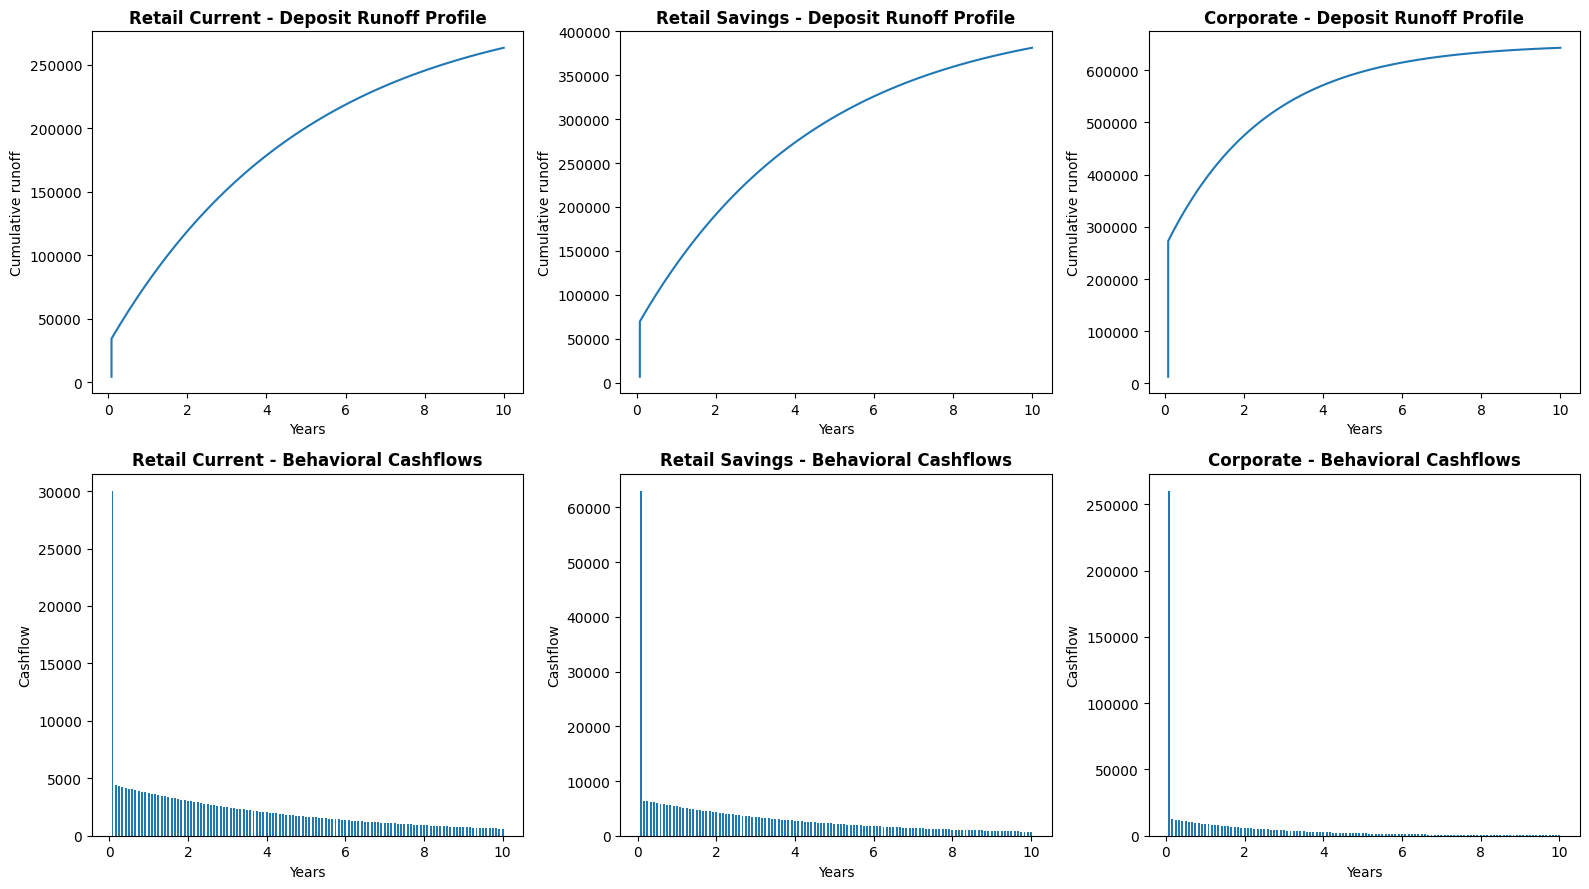

In [5]:
# plotting runoff curves
fig, axes = plt.subplots(2, 3, figsize = (16,9))

for col, (name, (t, cf)) in enumerate(behavioral_cashflows.items()):
    plot_runoff(axes[0, col], t, cf, f"{name} - Deposit Runoff Profile")
    plot_cashflows(axes[1, col], t, cf, f"{name} - Behavioral Cashflows")

plt.tight_layout()
plt.show()

In [6]:
# aggregated portfolio - bank level deposits
all_times = []
all_cashflows = []

for t, cf in behavioral_cashflows.values():
    all_times.extend(t)
    all_cashflows.extend(cf)

all_times = np.array(all_times)
all_cashflows = np.array(all_cashflows)

# sort by time
idx = np.argsort(all_times)
all_times = all_times[idx]
all_cashflows = all_cashflows[idx]

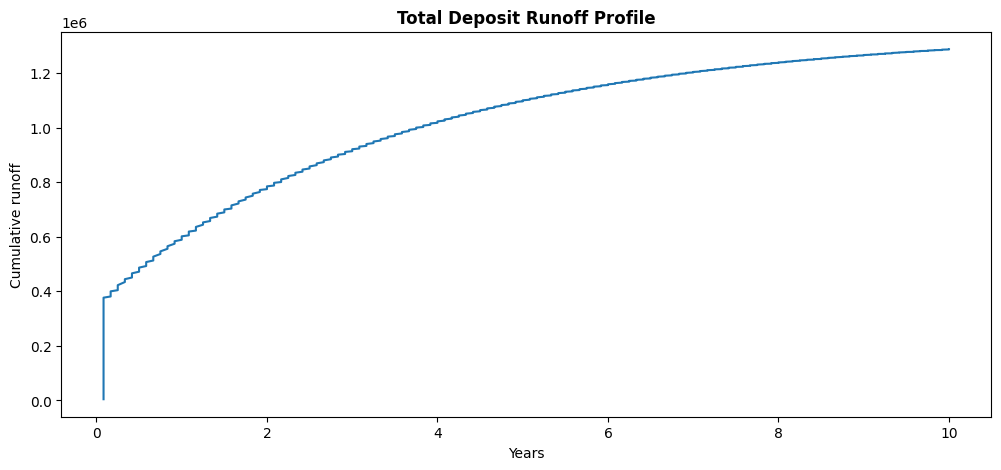

In [7]:
# plotting total deposits runoff
fig, ax = plt.subplots(figsize=(12, 5))
plot_runoff(ax, all_times, all_cashflows, 'Total Deposit Runoff Profile')
plt.show()


In [8]:
# weighted average runoff profile
weighted_maturity = np.sum(np.asarray(all_times) * np.asarray(all_cashflows)) / np.sum(all_cashflows)
print(f"Weighted Average Maturity of Total Deposits: {weighted_maturity:.2f}")

Weighted Average Maturity of Total Deposits: 2.18
